In [1]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
from analysis_utils import *
import os
os.makedirs("results", exist_ok=True)

### PERTURBATION ANALYSIS

In [ ]:
perturb = pd.read_parquet("benchmark_data/perturbation_results.parquet")
rep_names = [c[len("sim_"):] for c in perturb.columns if c.startswith("sim_")]
one_stage = calculate_similarity_correlation_data(perturb, rep_names, aggregation="one_stage")
table = pivot_correlation_table(one_stage["statistics"])
table.to_csv("results/perturbation_correlation_table.csv", index=False)
table.round(2)

r_MCC                                r_FI                    \
                    FG    TF    ID    LP    PP    TD    FG    TF    ID    LP   
perturbation                                                                   
change_threshold  0.56   NaN   NaN  0.73  0.78  0.62  0.77   NaN   NaN  0.80   
change_feature    0.31  0.08  0.25  0.56  0.54  0.38  0.69  0.17  0.51  0.78   
swap_nodes        0.33  0.08  0.27  0.61  0.61  0.39  0.65  0.16  0.49  0.79   
remove_nodes      0.61  0.44  0.70  0.80  0.84  0.90  0.83  0.61  0.79  0.96   
add_nodes          NaN   NaN   NaN   NaN   NaN   NaN  0.33  0.25  0.24  0.84   

                              
                    PP    TD  
perturbation                  
change_threshold  0.77  0.66  
change_feature    0.78  0.82  
swap_nodes        0.79  0.86  
remove_nodes      0.94  0.81  
add_nodes         0.64  0.42

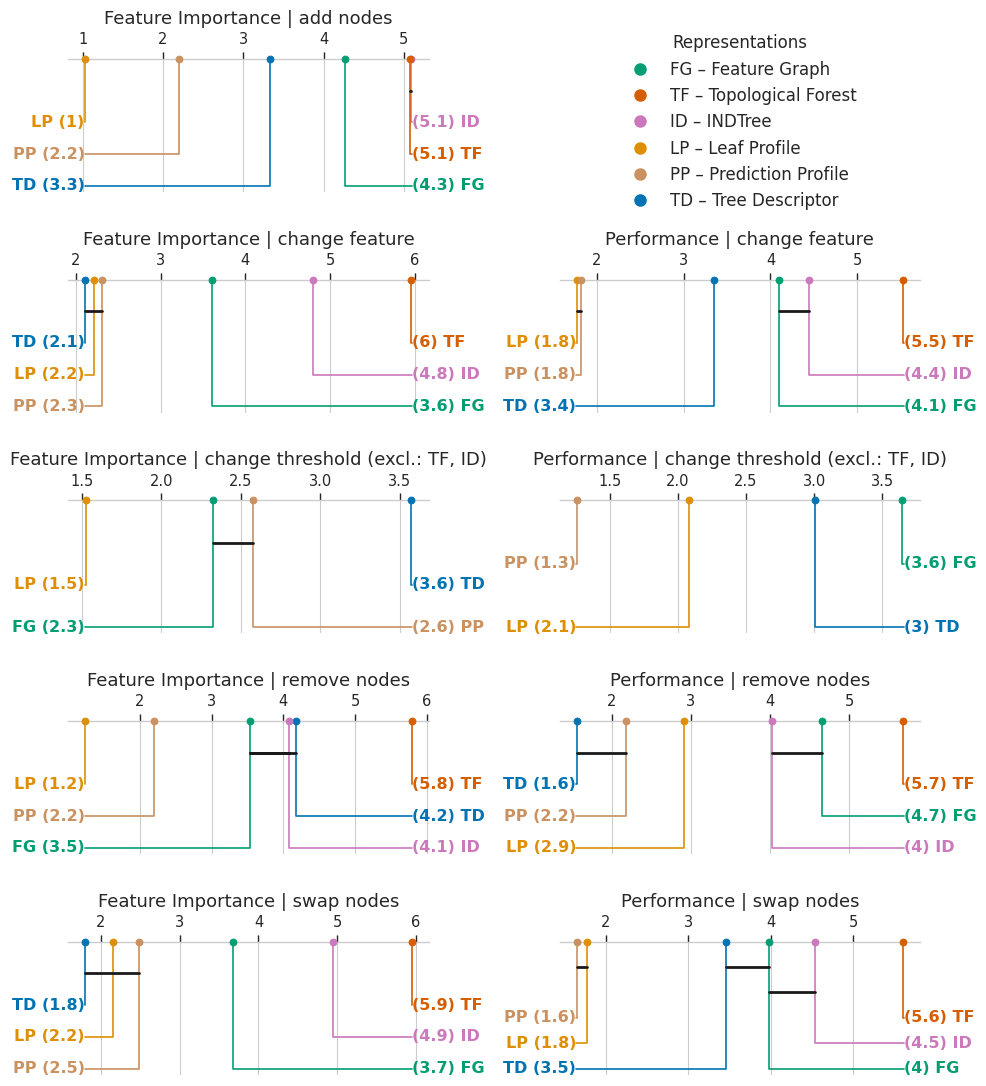

In [3]:
fig = plot_critical_difference_grid(
    one_stage["cluster_statistics"], rep_names,
    save_path="results/perturbation_critical_difference_grid.pdf"
)

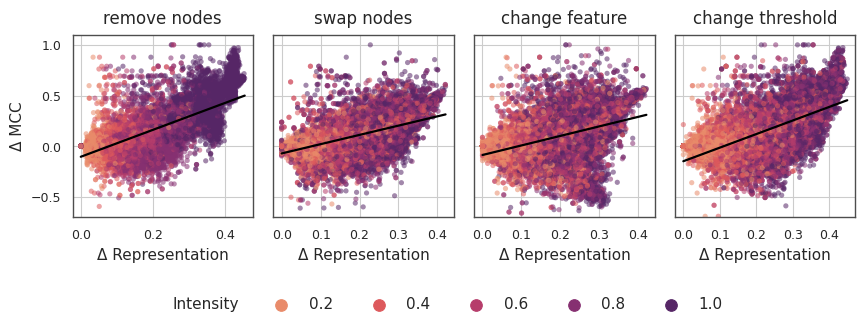

In [4]:
combos = [
    ("Leaf Profile", "remove_nodes"),
    ("Leaf Profile", "swap_nodes"),
    ("Leaf Profile", "change_feature"),
    ("Leaf Profile", "change_threshold"),
]

fig = plot_representative_scatter(
    one_stage["plot_data"],
    combos,
    type_="Performance",
    save_path="results/representative_scatter_leaf_profile_performance.png",
)

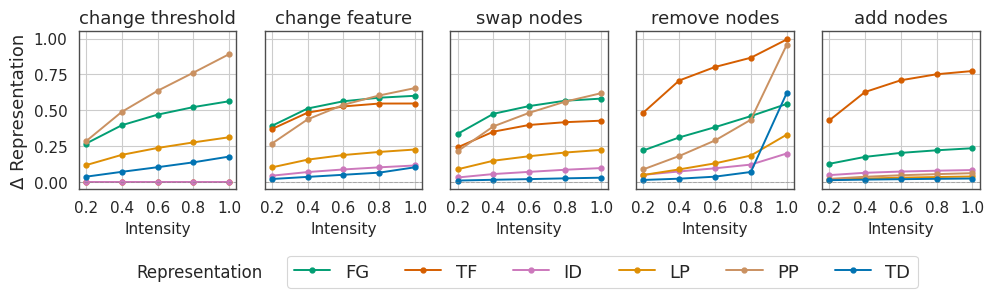

In [5]:
similarity_intensity_data = calculate_similarity_intensity_data(perturb)
fig = plot_similarity_vs_intensity_per_perturbation(similarity_intensity_data, 
                                                    save_path="results/perturbation_intensity_distance.pdf")

### SUBFOREST ANALYSIS

In [4]:
subforest = pd.read_parquet("benchmark_data/subforest_results.parquet")
subforest_scores = collapse_replicates(subforest)
validation_df = subforest_scores[subforest_scores["dataset"].isin(VALIDATION_DATASETS)]
test_df = subforest_scores[~subforest_scores["dataset"].isin(VALIDATION_DATASETS)]

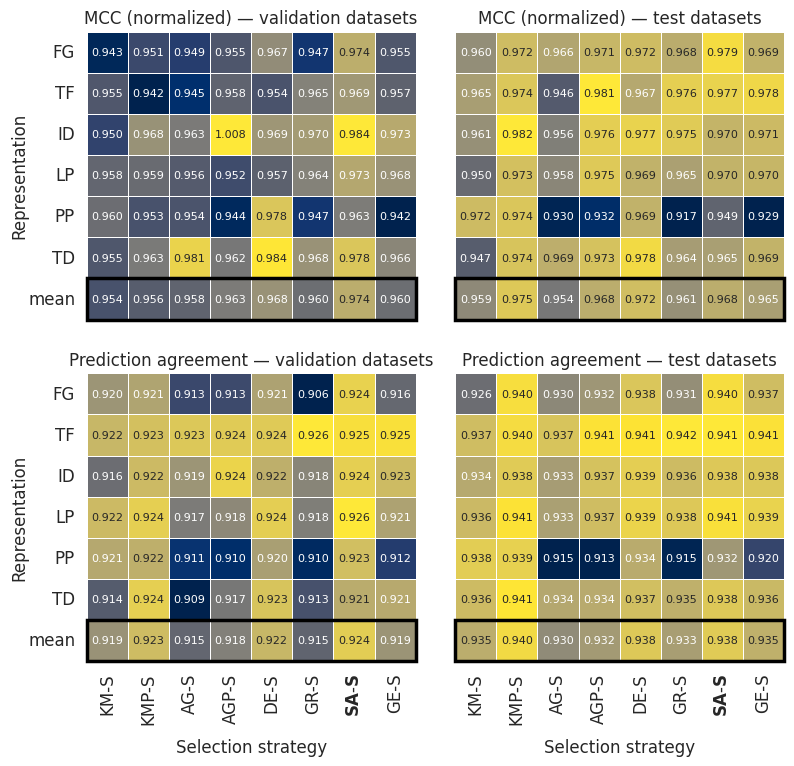

In [5]:
RECOVERY_METRICS = [
    ("mcc_recovery", "MCC (normalized)"),
    ("agreement_with_full_forest", "Prediction agreement"),
]
SPLITS = [
    ("validation", validation_df),
    ("test", test_df),
]

recovery_heatmap_tables = build_recovery_heatmap_tables(SPLITS, RECOVERY_METRICS)

fig = plot_recovery_heatmaps(
    recovery_heatmap_tables,
    SPLITS,
    RECOVERY_METRICS,
    save_path="results/subforest_selection_heatmap_value.pdf",
)

In [6]:
performance_by_rep = recovery_heatmap_tables[("validation", "MCC (normalized)")].mean(axis=0).sort_values(ascending=False)
stability_by_rep = recovery_heatmap_tables[("validation", "Prediction agreement")].mean(axis=0).sort_values(ascending=False)

print("=== Mean performance recovery per representation (validation) ===")
print(performance_by_rep.sort_values(ascending=False).index[0])

print("\n=== Mean stability recovery per representation (validation) ===")
print(stability_by_rep.sort_values(ascending=False).index[0])

best_overall = performance_by_rep.index[0]
strategy_map_overall_recovery = {rep: best_overall for rep in REP_NAMES}

=== Mean performance recovery per representation (validation) ===
combination-simulated_annealing

=== Mean stability recovery per representation (validation) ===
combination-simulated_annealing


In [7]:
unified = build_unified_table(subforest, best_overall)

size_list = {
    "tiny": [2, 3, 4, 5, 7],
    "small": [10, 14, 20, 27, 38],
    "medium": [53, 73, 101, 141, 195]
}
results = build_results_matrix(unified, size_list)
results.to_csv("results/subforest_selection_results.csv", index=False)
results.round(3)

,mcc_recovery\ntiny,mcc_recovery\nsmall,mcc_recovery\nmedium,agreement_with_full_forest\ntiny,agreement_with_full_forest\nsmall,agreement_with_full_forest\nmedium,stability_recovery\ntiny,stability_recovery\nsmall,stability_recovery\nmedium,fi_spearman_corr\ntiny,fi_spearman_corr\nsmall,fi_spearman_corr\nmedium
representation,,,,,,,,,,,,
TOM,0.921,0.991,1.001,0.867,0.930,0.962,0.957,1.060,1.126,0.809,0.915,0.963
TOA,0.916,0.993,1.004,0.869,0.933,0.965,1.002,1.029,1.113,0.807,0.911,0.963
RDM,0.856,0.985,1.006,0.851,0.930,0.971,0.761,0.927,1.001,0.801,0.918,0.974
FG,0.912,0.986,1.014,0.865,0.931,0.971,0.898,1.037,1.035,0.810,0.908,0.973
TF,0.905,0.993,1.008,0.869,0.931,0.972,1.020,1.106,1.053,0.816,0.919,0.974
ID,0.886,0.975,1.011,0.860,0.931,0.971,0.932,1.005,1.045,0.804,0.914,0.974
LP,0.878,0.989,1.009,0.864,0.933,0.971,1.053,1.079,1.078,0.790,0.913,0.974
PP,0.818,0.950,1.013,0.839,0.926,0.972,0.901,1.040,1.045,0.791,0.913,0.975
TD,0.855,0.987,1.011,0.855,0.931,0.972,0.909,1.097,1.062,0.773,0.911,0.972


In [8]:
thresholds = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]

# for each representation, select the rows corresponding to its assigned strategy (from strategy_map_overall_recovery), plus the k-varying baselines - only test datasets
method_table = build_method_table(test_df, strategy_map_overall_recovery)

# compute the mean recovery per (dataset, representation, selection_strategy, subforest_size) combination, grouping over folds
method_means = method_table.groupby(["dataset", "representation", "selection_strategy", "subforest_size"], dropna=False)["mcc_recovery"].mean().reset_index()

# determine min k for each recovery threshold
summary_mean_k = compute_mean_min_k(method_means, thresholds)

# compute the area under the min k curve for each representation
auc_df = compute_min_k_auc(summary_mean_k, log_scale=True)

<Axes: xlabel='Selection approach', ylabel='Area under $\\log_{10}(\\mathrm{min}\\ k)$-vs-threshold curve'>

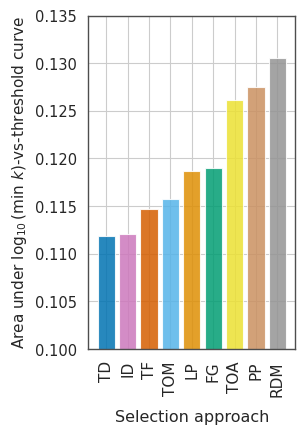

In [9]:
plot_min_k_auc_bar(auc_df,(0.1,0.135))

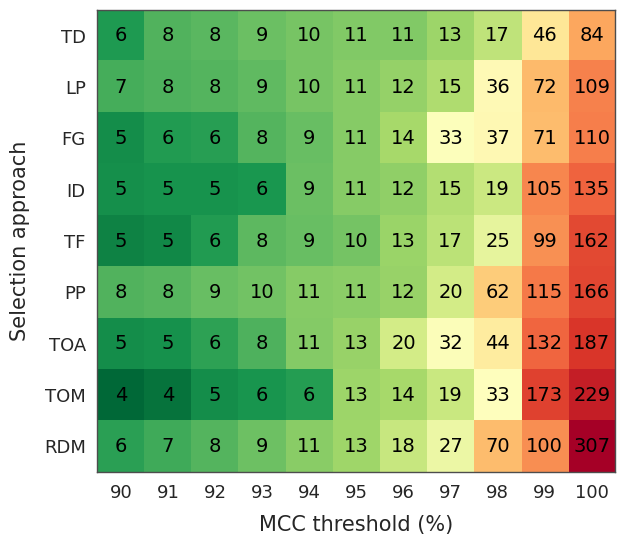

In [10]:
ax, ddf = plot_min_k_heatmap(summary_mean_k,stat="mean")

In [11]:
min_k_table_99_ratio = get_min_k_at_threshold(method_means, 0.99, ratio=True)
inf_time_99_ratio = get_inference_time_at_min_k(method_means, 0.99, inf_time_path ="benchmark_data/subforest_inference_time.csv")

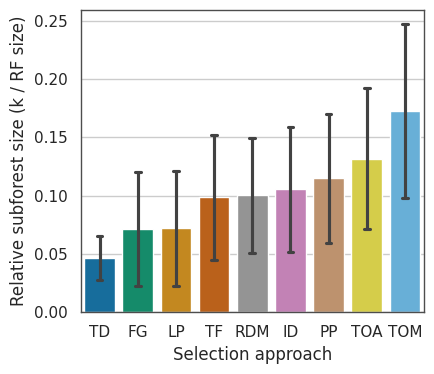

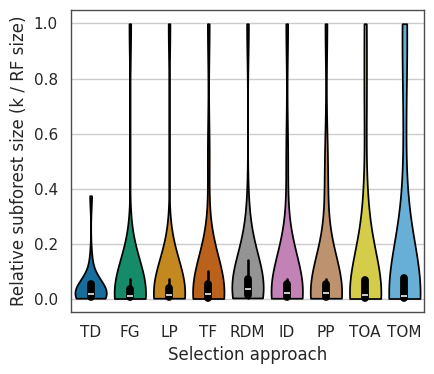

In [12]:
fig = plot_subforest_selection_at_threshold(min_k_table_99_ratio, "bar","Relative subforest size (k / RF size)", save_path="results/min_k_bar.pdf")
fig = plot_subforest_selection_at_threshold(min_k_table_99_ratio, "violin","Relative subforest size (k / RF size)", save_path="results/min_k_violin.pdf")
#"Relative inference time (vs. full forest)"

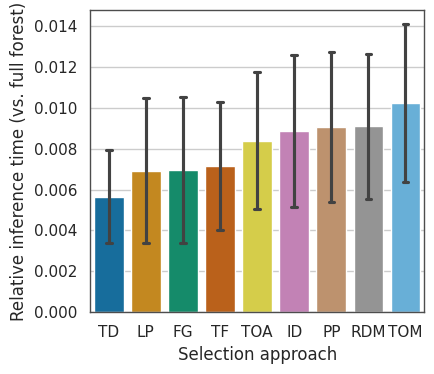

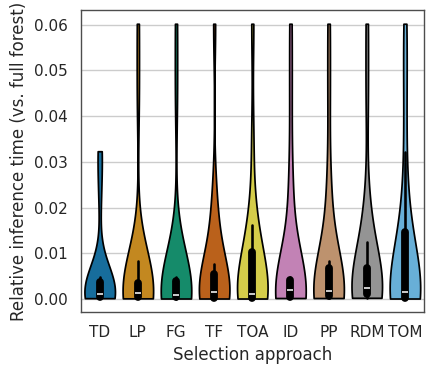

In [13]:
fig = plot_subforest_selection_at_threshold(inf_time_99_ratio, "bar","Relative inference time (vs. full forest)", save_path="results/min_k_inference_bar.pdf")
fig = plot_subforest_selection_at_threshold(inf_time_99_ratio, "violin","Relative inference time (vs. full forest)", save_path="results/min_k_inference_violin.pdf")

### RESOURCE BENCHMARK

In [18]:
data_represent = pd.read_parquet("benchmark_data/resource_represent.parquet")
data_similarity = pd.read_parquet("benchmark_data/resource_similarity.parquet")

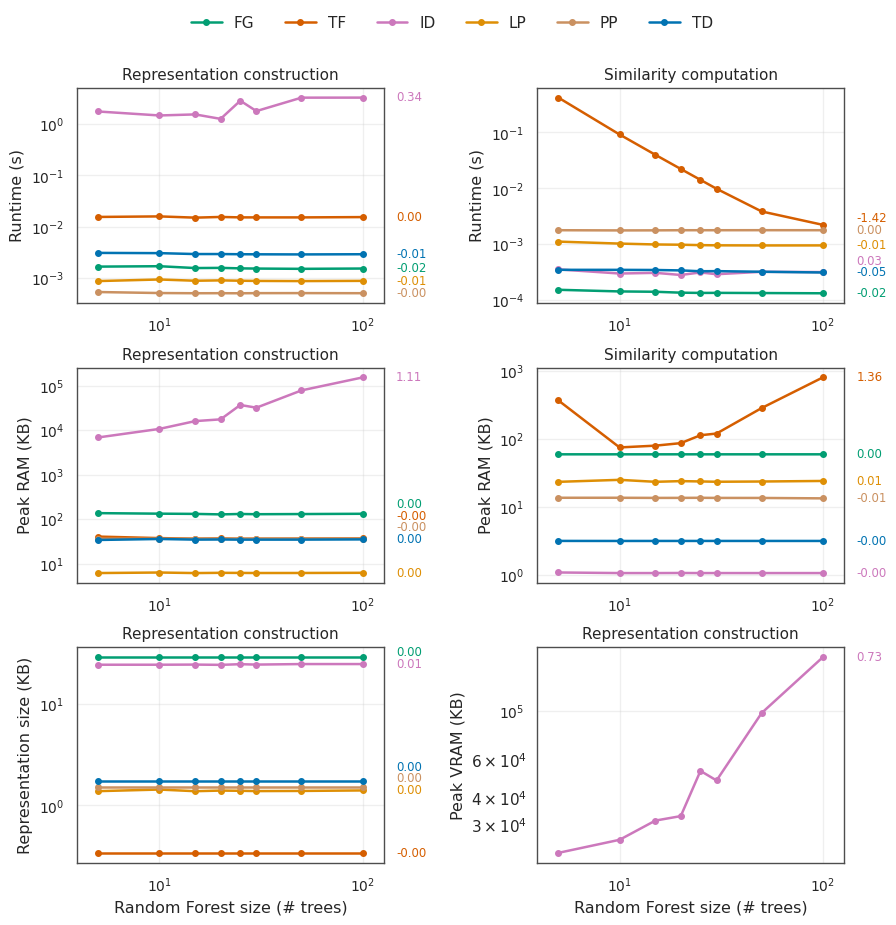

In [19]:
PANELS = [
    [("runtime", "Runtime (s)", "Representation construction", data_represent, None),
     ("runtime", "Runtime (s)", "Similarity computation", data_similarity, None)],
    [("peak_ram_kb", "Peak RAM (KB)", "Representation construction", data_represent, None),
     ("peak_ram_kb", "Peak RAM (KB)", "Similarity computation", data_similarity, None)],
    [("rep_size_kb", "Representation size (KB)", "Representation construction", data_represent, None),
     ("peak_vram_kb", "Peak VRAM (KB)", "Representation construction", data_represent, ["INDTree"])],
]

fig  = plot_resource_benchmark_panels( 
    PANELS,
    save_path="results/fig_resource_benchmark_summary.pdf",
)